In [4]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import nltk
import re
import numpy as np
import seaborn as sns
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud

# Ensure all necessary NLTK resources are downloaded
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

books = pd.read_csv('BX-Books.csv')
ratings = pd.read_csv('BX-Ratings.csv')
users = pd.read_csv('BX-Users.csv')


[nltk_data] Downloading package punkt to /Users/jerry/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/jerry/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/jerry/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
#check the number of missing value in each file
missing_books=books.isna().sum()
missing_ratings=ratings.isna().sum()
missing_users=users.isna().sum()
print("number of missing values:\n")
print(missing_ratings)
print(missing_books)
print(missing_users)

number of missing values:

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64
ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Book-Publisher         0
dtype: int64
User-ID             0
User-City          61
User-State          0
User-Country      669
User-Age        18952
dtype: int64


In [6]:
# Determine the uniqueness of UserID
id_counts = users['User-ID'].value_counts()


repeated_id = id_counts[id_counts > 1]

if not repeated_id.empty:
    print("repeated UserID:")
    print(repeated_id)
else:
    print("All UserID are unique")

All UserID are unique


In [7]:
# Determine the uniqueness of ISBN
isbn_counts = books['ISBN'].value_counts()


repeated_isbns = isbn_counts[isbn_counts > 1]

if not repeated_isbns.empty:
    print("repeated ISBN:")
    print(repeated_isbns)
else:
    print("All ISBN are unique")


All ISBN are unique


In [8]:
# Check the year count 
year_counts = books['Year-Of-Publication'].value_counts().sort_index()

print(year_counts)
# Years 0 and 2030 are invalid
#remove invalid data
books['Year-Of-Publication'] = books['Year-Of-Publication'].clip(upper=2024,lower=1)

Year-Of-Publication
0        314
1920       2
1927       1
1929       1
1930       1
        ... 
2002    1750
2003    1530
2004     475
2005       3
2030       3
Name: count, Length: 70, dtype: int64


In [9]:
# check rating
ratingbook = ratings['Book-Rating'].value_counts().sort_index()

print(ratingbook)

Book-Rating
1       712
2      1173
3      2559
4      3855
5     20080
6     16195
7     35437
8     51206
9     34822
10    38125
Name: count, dtype: int64


In [10]:
# check age
age = users["User-Age"].value_counts().sort_index()
print(age)

# remove the double quotes in age
users['User-Age'] = users['User-Age'].str.replace('"', '').replace('',pd.NA)

# implement missing data wihe -100

users['User-Age'].fillna(-100, inplace=True)
      
# remove double quotes in country
users['User-Country'] = users['User-Country'].str.replace('"', '').str.strip().str.lower().replace('',pd.NA)
users['User-Country'] = users['User-Country'].str.replace('[^a-zA-Z\s]', '', regex=True)

# conver to lower case
users['User-Country'] = users['User-Country'].str.lower()

# replace unstandard country name
country_replacements = {
    r'\b(?:u\.s\.a|us(?:a)?|united states(?: of america)?|united state|u s)\b': 'usa',
    r'\b(?:united kingdom|uk|britain|great britain|england)\b': 'uk',
    r'\b(?:new zealand|nz)\b': 'new zealand',
    r'\bcanada\b': 'canada',
    r'\bgermany\b': 'germany',
    r'\baustralia\b': 'australia'
}

for pattern, replacement in country_replacements.items():
    users['User-Country'] = users['User-Country'].str.replace(pattern, replacement, regex=True)


# print country count after process
print(users['User-Country'].value_counts())



User-Age
0      44
0"      1
1      44
1"      2
10     10
       ..
93"     1
94      1
96      1
97      1
99      1
Name: count, Length: 189, dtype: int64
User-Country
usa          34478
canada        4607
germany       1862
uk            1779
australia      980
             ...  
far away         1
moldova          1
van wert         1
tdzimi           1
ghana            1
Name: count, Length: 178, dtype: int64


/var/folders/6w/9gtqd_9j3rz41r1rzgxcd9h00000gn/T/ipykernel_42130/1461259428.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  users['User-Age'].fillna(-100, inplace=True)


We can find that There is missing country but no missing state.So we can find the existing state to find the according country to implement
a dictionary to fill in the missing country.

In [11]:
# Filter rows where 'User-Country' is NaN
missing_countries = users[users["User-Country"].isnull()]

# Drop rows where 'User-Country' is NaN from the original DataFrame to create a new DataFrame for mapping
existing = users.dropna(subset=['User-Country'])

# Create a dictionary that maps each 'User-State' to the first 'User-Country' found
dictionary = existing.groupby('User-State')['User-Country'].first().to_dict()

# Fill in the missing 'User-Country' values based on the state
for index, row in missing_countries.iterrows():
    state = row["User-State"]
    if state in dictionary:
        users.at[index, "User-Country"] = dictionary[state]


We set less significant countries to others 

In [12]:
others=users["User-Country"].value_counts()[users["User-Country"].value_counts()<100].index
users.loc[users["User-Country"].isin(others), "User-Country"]="others"

Text(0, 0.5, 'Count')

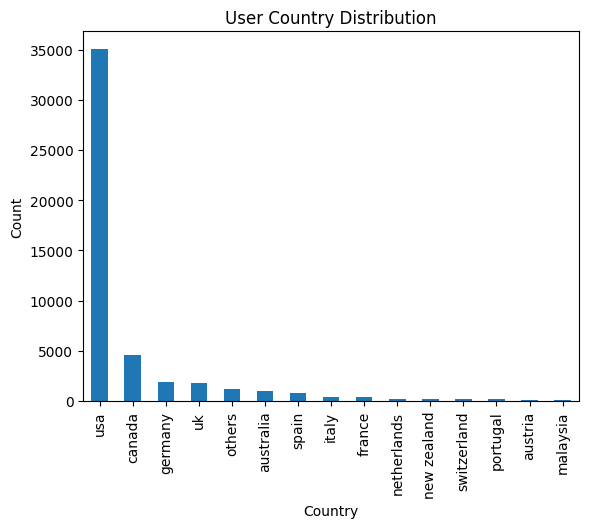

In [13]:
users["User-Country"].value_counts().plot(kind="bar")
plt.title("User Country Distribution")
plt.xlabel("Country")
plt.ylabel("Count")

set upper bound of age to 100. -100 represent missing age.

In [14]:
users["User-Age"]=users["User-Age"].astype(float).astype('int64')
users["User-Age"]=users["User-Age"].clip(upper=100)

ranged age groupe

/var/folders/6w/9gtqd_9j3rz41r1rzgxcd9h00000gn/T/ipykernel_42130/708024150.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  users["User-Age"].fillna(-1,inplace=True)
/var/folders/6w/9gtqd_9j3rz41r1rzgxcd9h00000gn/T/ipykernel_42130/708024150.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

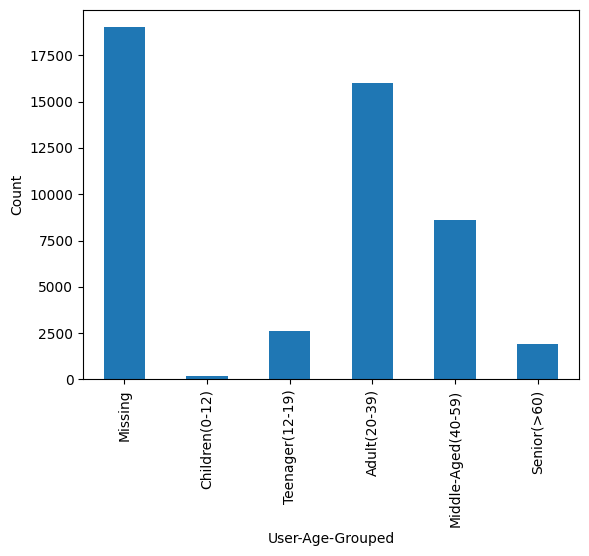

In [15]:
bins=[-100,0,12,19,39,59,100]
labels=["Missing","Children(0-12)","Teenager(12-19)","Adult(20-39)","Middle-Aged(40-59)","Senior(>60)"]

users["User-Age"].fillna(-1,inplace=True)
users["User-Age-Grouped"]=pd.cut(users["User-Age"],bins=bins,labels=labels,include_lowest=True)
plt.ylabel("Count")
users["User-Age-Grouped"].value_counts().sort_index().plot(kind="bar")

labels=[-1,0,1,2,3,4]
users["User-Age"].fillna(-1,inplace=True)
users["User-Age-Grouped"]=pd.cut(users["User-Age"],bins=bins,labels=labels,include_lowest=True)

just remove city bar makes it easyier to analyse reason <Hard to deal with missing data. In large datasets, users are distributed across thousands of different cities. The number of users per city may be quite low, making it difficult to conduct meaningful statistical analyses.Using broader geographic categories, such as country or state, can help models generalize better to new users instead of overfitting to specific small areas.>

In [16]:
users.drop(['User-City'],axis=1,inplace=True)

increase generalizability by setting minor state to others

In [17]:
top5states=users.groupby("User-Country")["User-State"].value_counts().groupby(level=0).nlargest(5).reset_index(level=0,drop=False)
toplist=top5states.index.get_level_values(1).tolist()

topdict={}
for country in top5states.index.get_level_values(0).unique():
    topdict[country]=top5states.loc[country].index.to_list()[:5]

for index,row in users.iterrows():
    country=row['User-Country']
    state=row['User-State']
    if country in topdict:
        if state not in topdict[country]:
            users.at[index,'User-State']="others"

print(users.head)

<bound method NDFrame.head of        User-ID   User-State User-Country  User-Age User-Age-Grouped
0            8      ontario       canada      -100               -1
1            9       others          usa      -100               -1
2           16       others          usa      -100               -1
3           17       others          usa      -100               -1
4           19       others          usa        14                1
...        ...          ...          ...       ...              ...
48294   278846      ontario       canada        23                2
48295   278849      ontario       canada        23                2
48296   278851        texas          usa        33                2
48297   278852   queensland    australia        32                2
48298   278854       others          usa      -100               -1

[48299 rows x 5 columns]>


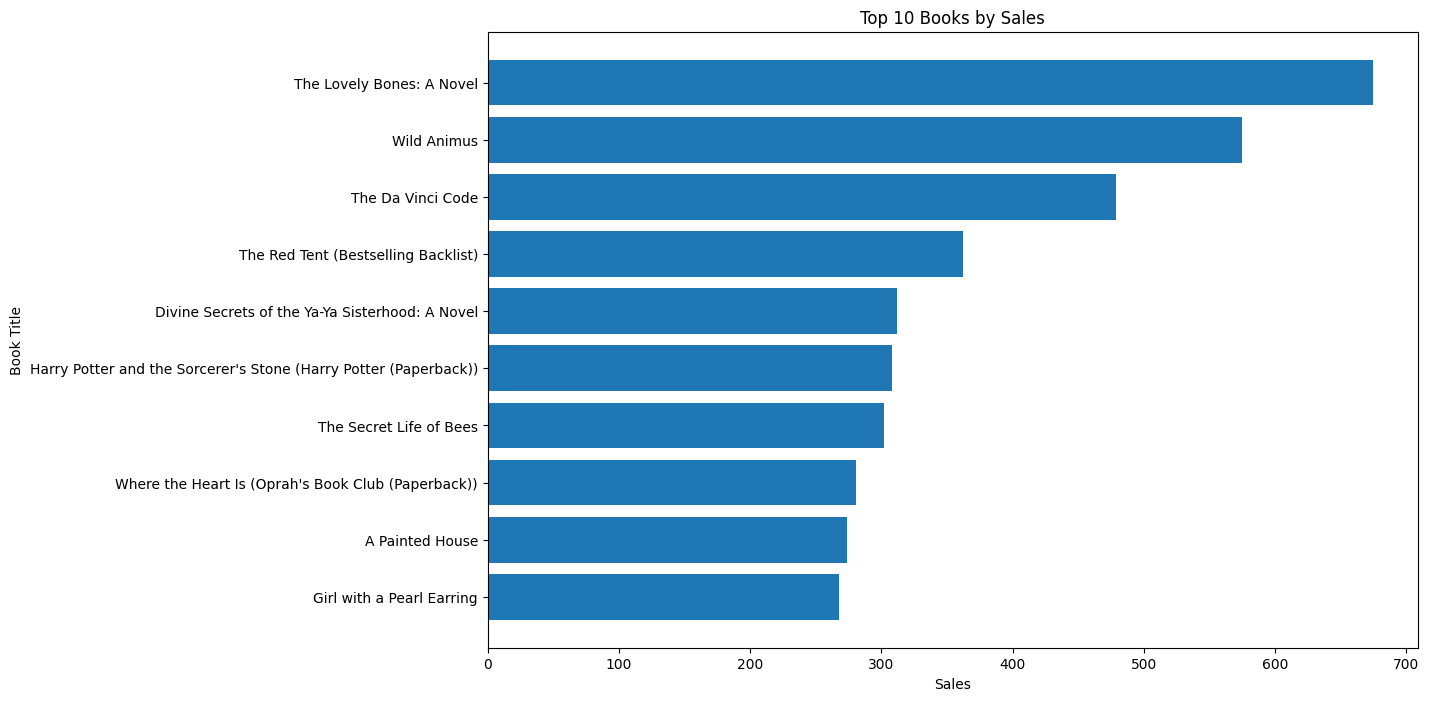

In [18]:
#Plot a histogram of authors vs. sales
data = pd.merge(ratings, books, on='ISBN')
sales_counts = data['ISBN'].value_counts().reset_index()
sales_counts.columns = ['ISBN', 'Sales']
sales_counts = sales_counts.merge(books[['ISBN', 'Book-Title']], on='ISBN')

top10_sales = sales_counts.head(10)

plt.figure(figsize=(12, 8))
plt.barh(top10_sales['Book-Title'], top10_sales['Sales'])
plt.xlabel('Sales')
plt.ylabel('Book Title')
plt.title('Top 10 Books by Sales')
plt.gca().invert_yaxis()
plt.show()




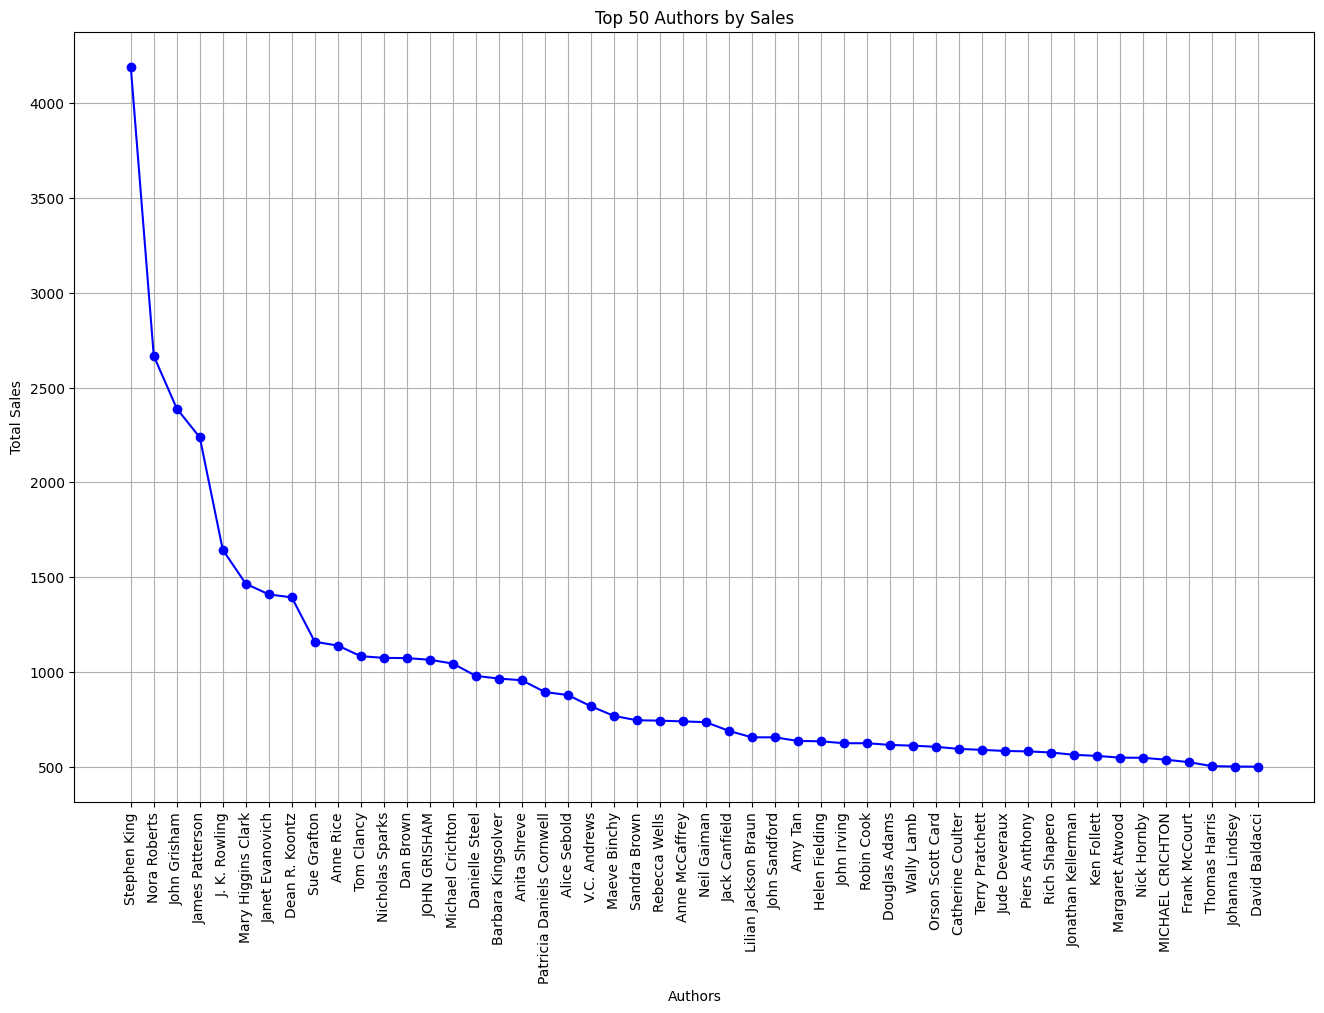

In [19]:
#Plot a line chart of authors vs. sales
sales_counts = sales_counts.merge(books[['ISBN', 'Book-Author']], on='ISBN')

author_sales = sales_counts.groupby('Book-Author')['Sales'].sum().reset_index()

top_authors = author_sales.sort_values(by='Sales', ascending=False).head(50)


plt.figure(figsize=(16, 10))  
plt.plot(top_authors['Book-Author'], top_authors['Sales'], marker='o', linestyle='-', color='b')
plt.xlabel('Authors')
plt.ylabel('Total Sales')
plt.title('Top 50 Authors by Sales')
plt.xticks(rotation=90)  
plt.grid(True)  
plt.show()





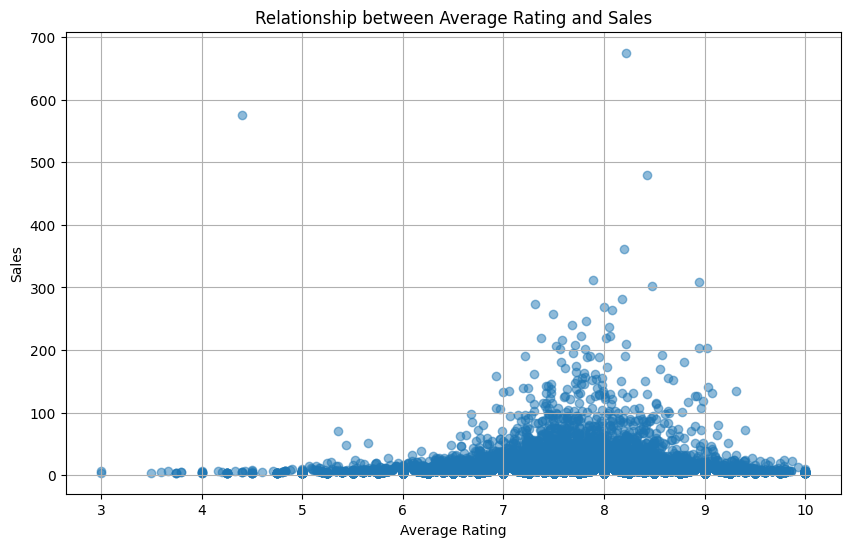

In [20]:
# Calculate average rating
average_ratings = ratings.groupby('ISBN')['Book-Rating'].mean().reset_index()
average_ratings.columns = ['ISBN', 'Average-Rating']
data = sales_counts.merge(average_ratings, on='ISBN')


plt.figure(figsize=(10, 6))
plt.scatter(data['Average-Rating'], data['Sales'], alpha=0.5)
plt.title('Relationship between Average Rating and Sales')
plt.xlabel('Average Rating')
plt.ylabel('Sales')
plt.grid(True)
plt.show()
#Except some outliers we can see that rating and sales are normally distributted.
#We would suggest book shop buy more books that ratings are around 7-9 for best sales instead of the highest rating books


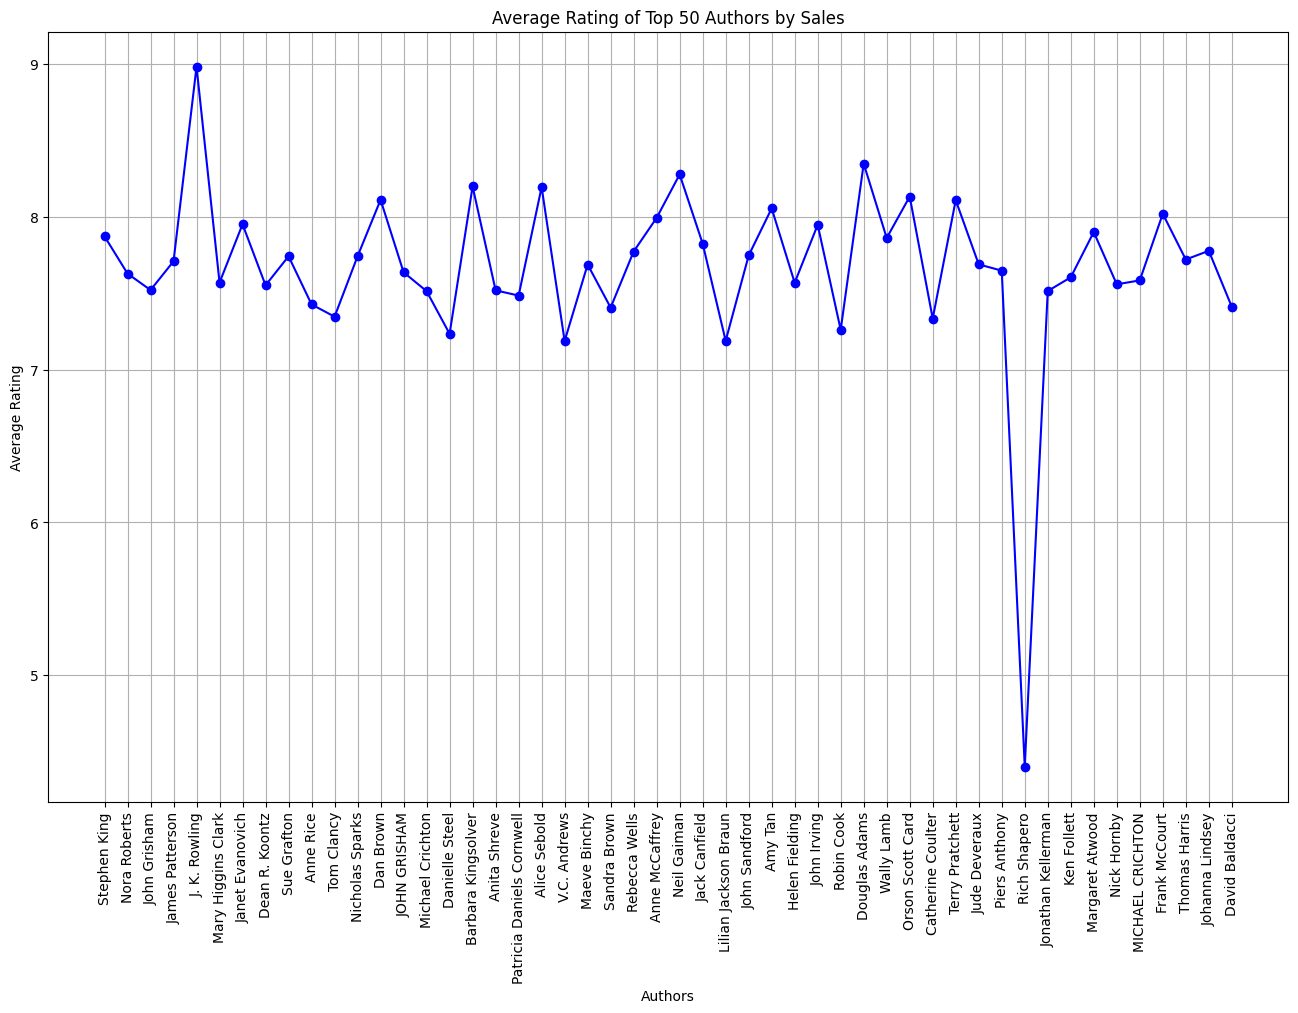

In [21]:
# Merge sales_counts with ratings to get the ratings for each book
sales_ratings = sales_counts.merge(ratings, on='ISBN')

# Calculate the average rating for each author
average_rating_by_author = sales_ratings.groupby('Book-Author')['Book-Rating'].mean().reset_index()

# Select the top 50 authors by sales
top_authors_with_ratings = top_authors.merge(average_rating_by_author, on='Book-Author')

# Plot the line chart
plt.figure(figsize=(16, 10))  
plt.plot(top_authors_with_ratings['Book-Author'], top_authors_with_ratings['Book-Rating'], marker='o', linestyle='-', color='b')
plt.xlabel('Authors')
plt.ylabel('Average Rating')
plt.title('Average Rating of Top 50 Authors by Sales')
plt.xticks(rotation=90)  
plt.grid(True)  
plt.show()

ENCODING SECTION
# We chose label encoding instead of one hot encoding because there is various country,state... It could lead to Curse of Dimension 

In [22]:
import sklearn
from sklearn.preprocessing import LabelEncoder

LE=LabelEncoder()

users["User-Country-Encoded"]=LE.fit_transform(users["User-Country"])
users["User-State-Encoded"]=LE.fit_transform(users["User-State"])

users_encoded=users[["User-ID","User-Age","User-Age-Grouped","User-Country-Encoded","User-State-Encoded"]]

print(users.head(5))

   User-ID User-State User-Country  User-Age User-Age-Grouped  \
0        8    ontario       canada      -100               -1   
1        9     others          usa      -100               -1   
2       16     others          usa      -100               -1   
3       17     others          usa      -100               -1   
4       19     others          usa        14                1   

   User-Country-Encoded  User-State-Encoded  
0                     2                  36  
1                    14                  68  
2                    14                  68  
3                    14                  68  
4                    14                  68  


In [23]:
books["Book-Author-Encoded"]=LE.fit_transform(books['Book-Author'])
books["Book-Publisher-Encoded"]=LE.fit_transform(books['Book-Publisher'])
books["Year-of-Publication-Encoded"]=LE.fit_transform(books['Year-Of-Publication'])

print(books.head(5))

         ISBN                                         Book-Title  \
0  0002005018                                       Clara Callan   
1  0374157065  Flu: The Story of the Great Influenza Pandemic...   
2  0399135782                             The Kitchen God's Wife   
3  0440234743                                      The Testament   
4  0452264464               Beloved (Plume Contemporary Fiction)   

            Book-Author  Year-Of-Publication         Book-Publisher  \
0  Richard Bruce Wright                 2001  HarperFlamingo Canada   
1      Gina Bari Kolata                 1999   Farrar Straus Giroux   
2               Amy Tan                 1991       Putnam Pub Group   
3          John Grisham                 1999                   Dell   
4         Toni Morrison                 1994                  Plume   

   Book-Author-Encoded  Book-Publisher-Encoded  Year-of-Publication-Encoded  
0                 5190                     522                           64  
1       

In [24]:

# Initialize lemmatizer and load stopwords
WL = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def text_process(text):
    # Convert to lower case
    text = str(text).lower()
    # Preserve only letters
    text = re.sub(r'[^a-z\s]', ' ', text)  # Using 'a-z' as text is already in lower case
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [WL.lemmatize(word) for word in tokens if word not in stop_words]
    # Return the processed text as a single string
    return ' '.join(tokens)


books["Book-Title"] = books['Book-Title'].apply(text_process)

print(books["Book-Title"])

0                                             clara callan
1        flu story great influenza pandemic search viru...
2                                         kitchen god wife
3                                                testament
4                       beloved plume contemporary fiction
                               ...                        
18180                                             love etc
18181                           wit whimsy mary engelbreit
18182                               los detective salvajes
18183                             ice house tv tie edition
18184          trouble business vintage crime black lizard
Name: Book-Title, Length: 18185, dtype: object


In [25]:

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec=TfidfVectorizer()
tfidf_matrix=tfidf_vec.fit_transform(books['Book-Title'])

#convert to dataframe
tfidf_df=pd.DataFrame(tfidf_matrix.toarray(),columns=tfidf_vec.get_feature_names_out(),index=books.index)


In [26]:
# we need to reduce dimensionality using pca. but tfidf seems not good here
# Initialize PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca.fit(tfidf_df)

# Transform the data according to PCA
tfidf_pca = pca.transform(tfidf_df)

# Get the percentage of variance explained by the 1 component
pct = pca.explained_variance_ratio_

print(f"\nTotal percentage of variance explained by {len(pct)} component(s): {sum(pct) * 100:.2f}%")



Total percentage of variance explained by 3 component(s): 1.32%


In [27]:

from gensim.models import Word2Vec
from sklearn.decomposition import PCA

# Concatenating the text data from different columns 
tokentitle = [title.split() for title in books['Book-Title']]

# Train Word2Vec model
model = Word2Vec(sentences=tokentitle, vector_size=1000, window=5, min_count=1, workers=4)

# Initialize embeddings list
embeddings = []

# Generate embeddings for each title
for title in tokentitle:
    title_embeddings = [model.wv[word] for word in title if word in model.wv]
    if title_embeddings:
        embeddings.append(np.mean(title_embeddings, axis=0))
    else:
        embeddings.append(np.zeros(1000))

# Create a DataFrame from embeddings
Word2Vec_df = pd.DataFrame(embeddings)

# Initialize PCA
pca = PCA(n_components=1)
pca.fit(Word2Vec_df)

# Transform the data according to PCA
Word2Vec_pca = pca.transform(Word2Vec_df)

# Get the percentage of variance explained by the 1 component
pct = pca.explained_variance_ratio_

print(f"\nTotal percentage of variance explained by {len(pct)} component(s): {sum(pct) * 100:.2f}%")



Total percentage of variance explained by 1 component(s): 99.30%


In [28]:
books_processed =books[["ISBN","Year-Of-Publication","Book-Author-Encoded","Book-Publisher-Encoded"]]
books_processed["Book-Title-Processed"]=Word2Vec_pca

print(books_processed.head(5))

         ISBN  Year-Of-Publication  Book-Author-Encoded  \
0  0002005018                 2001                 5190   
1  0374157065                 1999                 2169   
2  0399135782                 1991                  240   
3  0440234743                 1999                 3079   
4  0452264464                 1994                 6132   

   Book-Publisher-Encoded  Book-Title-Processed  
0                     522             -0.222388  
1                     406              0.030835  
2                     952             -0.019354  
3                     287             -0.222423  
4                     910              0.032783  


/var/folders/6w/9gtqd_9j3rz41r1rzgxcd9h00000gn/T/ipykernel_42130/3930880423.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books_processed["Book-Title-Processed"]=Word2Vec_pca


In [29]:
# Merge ratings with books
merged_data = pd.merge(ratings, books_processed, on='ISBN', how='inner')

# Merge merged_data with users
merged_data = pd.merge(merged_data, users_encoded, on='User-ID', how='inner')

# User id and ISBN are not useful heare so we just drop them
merged_data = merged_data.drop(columns=["User-ID","ISBN"])

print(merged_data.head(3))

#merged_data.to_csv('merged_data.csv', index=False)

   Book-Rating  Year-Of-Publication  Book-Author-Encoded  \
0            7                 2001                 2556   
1            8                 1999                 5762   
2            5                 1996                 3501   

   Book-Publisher-Encoded  Book-Title-Processed  User-Age User-Age-Grouped  \
0                     325              0.047630      -100               -1   
1                    1062              0.262842        19                1   
2                    1081             -0.070218        32                2   

   User-Country-Encoded  User-State-Encoded  
0                    14                  10  
1                     2                   1  
2                     4                  18  


standard scalar for all numerical data

In [30]:

from sklearn.preprocessing import StandardScaler

scalar=StandardScaler()

merged_data_scalar=merged_data.copy()

columns=["Year-Of-Publication","Book-Author-Encoded","Book-Publisher-Encoded"
         ,"Book-Title-Processed","User-Age","User-Age-Grouped","User-Country-Encoded","User-State-Encoded"]

merged_data_scalar[columns]=scalar.fit_transform(merged_data[columns])


forcast bookrating for recommending

check there is no colinearality issue.We can see except user age and grouped user age,there is no such issue,It's natural they have correlation.

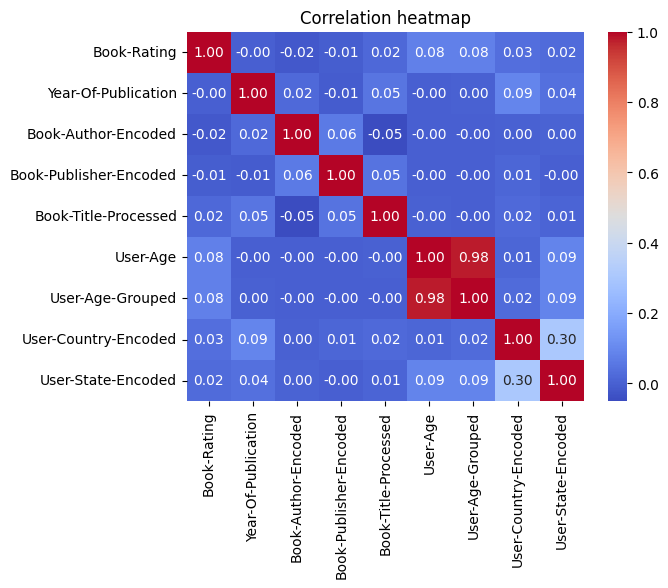

In [31]:
correletion=merged_data_scalar.corr()
plt.figure()
sns.heatmap(correletion,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

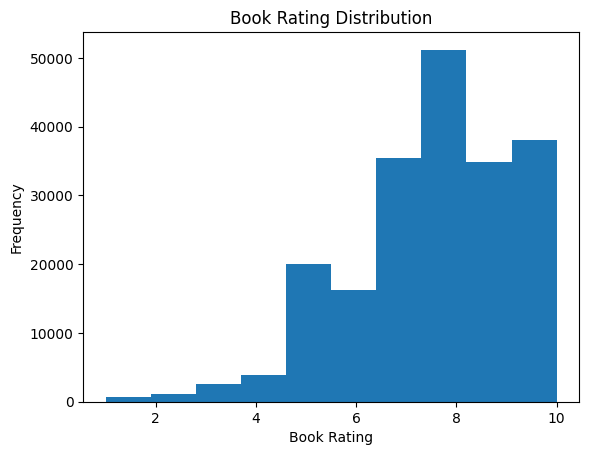

In [32]:
#let's check rating distribution first
plt.hist(merged_data_scalar['Book-Rating'],bins=10)
plt.title("Book Rating Distribution")
plt.xlabel("Book Rating")
plt.ylabel("Frequency")
plt.show()

Linear Regressor

In [33]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error,mean_absolute_error,classification_report,confusion_matrix

In [34]:
x=merged_data_scalar.drop(columns=['Book-Rating'])
y=merged_data_scalar['Book-Rating']
#train test split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

#we use 5fold cross validation here
LR=LinearRegression()
linear_scores=cross_val_score(LR,x,y,cv=5,scoring='neg_mean_squared_error')
linear_rmsescores=(-linear_scores)**0.5

print("Linear 5Fold Cross Validation RMSE Scores:")
print(linear_rmsescores)
print("Linear 5Fold Cross Validation Mean RMSE Scores:")
print(linear_rmsescores.mean())

Linear 5Fold Cross Validation RMSE Scores:
[1.79810575 1.75036295 1.78119146 1.77787453 1.81464709]
Linear 5Fold Cross Validation Mean RMSE Scores:
1.784436356654919


In [35]:
#decision tree regerssor gets even worse
#we use 5fold cross validation here
DT=DecisionTreeRegressor()
linear_scores=cross_val_score(DT,x,y,cv=5,scoring='neg_mean_squared_error')
linear_rmsescores=(-linear_scores)**0.5

print("Linear 5Fold Cross Validation RMSE Scores:")
print(linear_rmsescores)
print("Linear 5Fold Cross Validation Mean RMSE Scores:")
print(linear_rmsescores.mean())

Linear 5Fold Cross Validation RMSE Scores:
[2.41841443 2.41139381 2.39192604 2.40159458 2.40974244]
Linear 5Fold Cross Validation Mean RMSE Scores:
2.4066142612009402


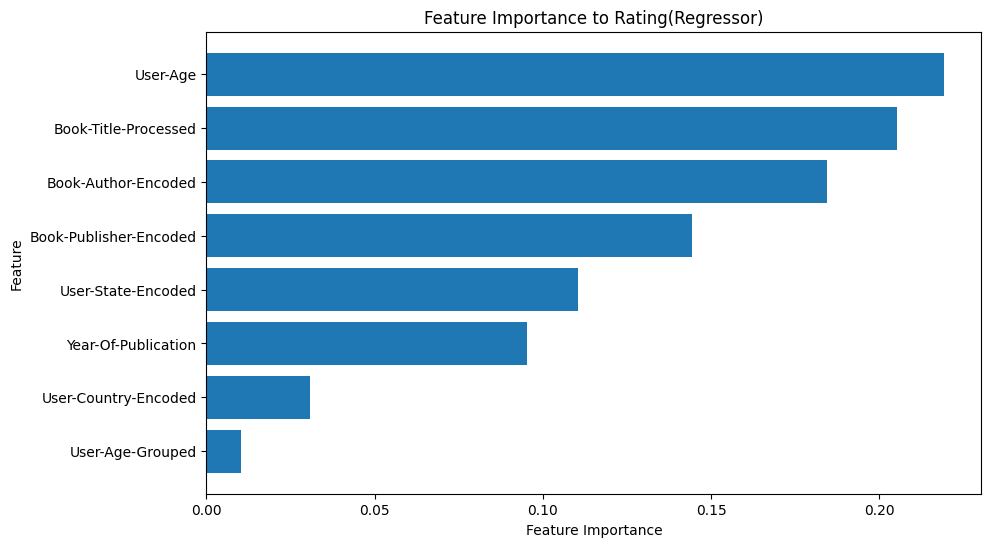

In [36]:
DT.fit(x,y)
feature_importance=DT.feature_importances_
name=x.columns
sorted_index= np.argsort(feature_importance)

plt.figure(figsize=(10,6))
plt.barh(range(len(sorted_index)),feature_importance[sorted_index])
plt.yticks(range(len(sorted_index)),[name[i] for i in sorted_index])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance to Rating(Regressor)")
plt.show()

 We try classifier 

 prediction for lower class isn't performing well due to least information
 decision tree is slightly better

KNN Classifier Metrics:
Accuracy: 0.2275
F1 score: 0.0992
Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       143
           2       0.12      0.01      0.02       270
           3       0.00      0.00      0.00       501
           4       0.00      0.00      0.00       761
           5       0.18      0.06      0.09      4049
           6       0.10      0.01      0.02      3219
           7       0.19      0.16      0.17      7071
           8       0.26      0.55      0.35     10186
           9       0.20      0.12      0.14      7028
          10       0.25      0.24      0.24      7605

    accuracy                           0.24     40833
   macro avg       0.13      0.11      0.10     40833
weighted avg       0.20      0.24      0.20     40833



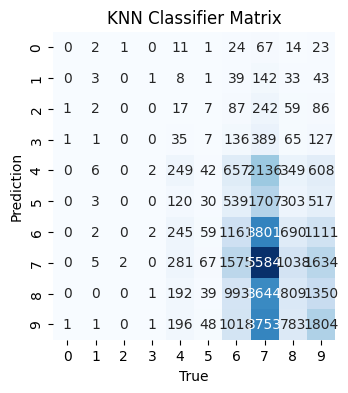

In [37]:

#Decisio tree classifier
DT_classifier=DecisionTreeClassifier(random_state=42)
DT_accuracy= cross_val_score(DT_classifier,x,y,cv=5,scoring='accuracy')
DT_f1= cross_val_score(DT_classifier,x,y,cv=5,scoring='f1_macro')

DT_classifier.fit(xtrain,ytrain)
DT_prediction=DT_classifier.predict(xtest)

DTconfusion_matrix=confusion_matrix(ytest,DT_prediction)
DTclassification_report=classification_report(ytest,DT_prediction)

#Knn calssifier
#We chose the best k value among a certain range
kvalues=np.arange(1,40)
mean_scores = []
for k in kvalues:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, xtrain, ytrain, cv=5, scoring='accuracy')
    mean_scores.append(np.mean(scores))

optimal_k = kvalues[np.argmax(mean_scores)]


KNN=KNeighborsClassifier(n_neighbors=k)

KNN_accuracy= cross_val_score(KNN,x,y,cv=5,scoring='accuracy')
KNN_f1= cross_val_score(KNN,x,y,cv=5,scoring='f1_macro')

KNN.fit(xtrain,ytrain)
KNN_prediction=KNN.predict(xtest)

KNNconfusion_matrix=confusion_matrix(ytest,KNN_prediction)
KNNclassification_report=classification_report(ytest,KNN_prediction)


print("KNN Classifier Metrics:")
print(f'Accuracy: {np.mean(KNN_accuracy):.4f}')
print(f'F1 score: {np.mean(KNN_f1):.4f}')
print("Classification Report:")
print(KNNclassification_report)



plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.heatmap(KNNconfusion_matrix,annot=True,fmt="d",cmap="Blues",cbar=False)
plt.ylabel("Prediction")
plt.xlabel("True")
plt.title("KNN Classifier Matrix")
plt.show()

DecisionTreeClassifier Metrics:
Accuracy: 0.1866
F1 score: 0.1143
Classification Report:
              precision    recall  f1-score   support

           1       0.04      0.05      0.05       143
           2       0.02      0.02      0.02       270
           3       0.03      0.03      0.03       501
           4       0.03      0.03      0.03       761
           5       0.15      0.17      0.16      4049
           6       0.10      0.10      0.10      3219
           7       0.20      0.20      0.20      7071
           8       0.27      0.27      0.27     10186
           9       0.21      0.19      0.20      7028
          10       0.27      0.24      0.26      7605

    accuracy                           0.21     40833
   macro avg       0.13      0.13      0.13     40833
weighted avg       0.21      0.21      0.21     40833



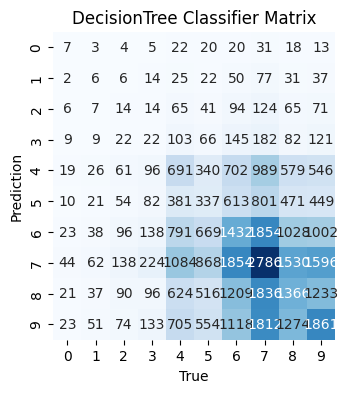

In [38]:
print("DecisionTreeClassifier Metrics:")
print(f'Accuracy: {np.mean(DT_accuracy):.4f}')
print(f'F1 score: {np.mean(DT_f1):.4f}')
print("Classification Report:")
print(DTclassification_report)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.heatmap(DTconfusion_matrix,annot=True,fmt="d",cmap="Blues",cbar=False)
plt.ylabel("Prediction")
plt.xlabel("True")
plt.title("DecisionTree Classifier Matrix")
plt.show()

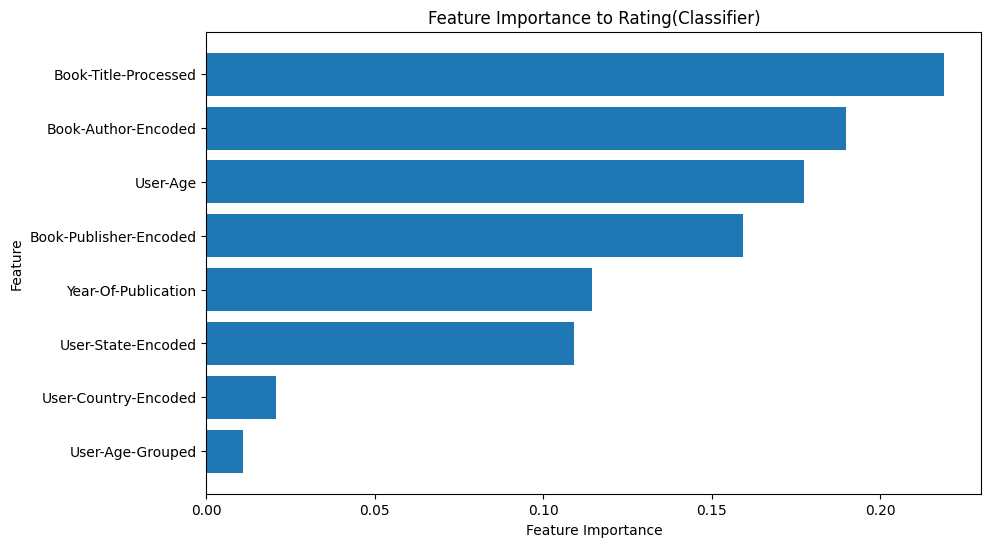

In [39]:
#analyse feature importance for classifier
DT_classifier.fit(x,y)
feature_importance=DT_classifier.feature_importances_
name=x.columns
sorted_index= np.argsort(feature_importance)

plt.figure(figsize=(10,6))
plt.barh(range(len(sorted_index)),feature_importance[sorted_index])
plt.yticks(range(len(sorted_index)),[name[i] for i in sorted_index])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance to Rating(Classifier)")
plt.show()

Recommendation Syetem Section

First we do the same preprocess to new test set as we did before.

In [40]:
books_test=pd.read_csv("BX-Newbooks.csv")
ratings_test=pd.read_csv("BX-NewBooksRatings.csv")
users_test=pd.read_csv("BX-NewBooksUsers.csv")

books_test['Year-Of-Publication'] = books_test['Year-Of-Publication'].clip(upper=2024, lower=1)
users_test['User-Age'] = users_test['User-Age'].str.replace('"', '').replace('', pd.NA)
users_test['User-Age'].fillna(-100, inplace=True)
users_test['User-Country'] = users_test['User-Country'].str.replace('"', '').str.strip().str.lower().replace('', pd.NA)
users_test['User-Country'] = users_test['User-Country'].str.replace('[^a-zA-Z\s]', '', regex=True)

# convert to lower case
users_test['User-Country'] = users_test['User-Country'].str.lower()

# replace unstandard country name
country_replacements = {
    r'\b(?:u\.s\.a|us(?:a)?|united states(?: of america)?|united state|u s)\b': 'usa',
    r'\b(?:united kingdom|uk|britain|great britain|england)\b': 'uk',
    r'\b(?:new zealand|nz)\b': 'new zealand',
    r'\bcanada\b': 'canada',
    r'\bgermany\b': 'germany',
    r'\baustralia\b': 'australia'
}

for pattern, replacement in country_replacements.items():
    users_test['User-Country'] = users_test['User-Country'].str.replace(pattern, replacement, regex=True)

# Filter rows where 'User-Country' is NaN
missing_countries = users_test[users_test["User-Country"].isnull()]

# Drop rows where 'User-Country' is NaN from the original DataFrame to create a new DataFrame for mapping
existing = users_test.dropna(subset=['User-Country'])

# Create a dictionary that maps each 'User-State' to the first 'User-Country' found
dictionary = existing.groupby('User-State')['User-Country'].first().to_dict()

# Fill in the missing 'User-Country' values based on the state
for index, row in missing_countries.iterrows():
    state = row["User-State"]
    if state in dictionary:
        users_test.at[index, "User-Country"] = dictionary[state]

others = users_test["User-Country"].value_counts()[users_test["User-Country"].value_counts() < 100].index
users_test.loc[users_test["User-Country"].isin(others), "User-Country"] = "Others"

users_test["User-Age"] = users_test["User-Age"].astype(float).astype('int64')
users_test["User-Age"] = users_test["User-Age"].clip(upper=100)

labels = [-1, 0, 1, 2, 3, 4]

users_test["User-Age"].fillna(-1, inplace=True)
users_test["User-Age-Grouped"] = pd.cut(users_test["User-Age"], bins=bins, labels=labels, include_lowest=True)
users_test.drop(['User-City'], axis=1, inplace=True)

top5states = users_test.groupby("User-Country")["User-State"].value_counts().groupby(level=0).nlargest(5).reset_index(level=0, drop=False)
toplist = top5states.index.get_level_values(1).tolist()

topdict = {}
for country in top5states.index.get_level_values(0).unique():
    topdict[country] = top5states.loc[country].index.to_list()[:5]

for index, row in users_test.iterrows():
    country = row['User-Country']
    state = row['User-State']
    if country in topdict:
        if state not in topdict[country]:
            users_test.at[index, 'User-State'] = "others"

LE = LabelEncoder()

users_test["User-Country-Encoded"] = LE.fit_transform(users_test["User-Country"])
users_test["User-State-Encoded"] = LE.fit_transform(users_test["User-State"])

users_encoded_test = users_test[["User-ID", "User-Age", "User-Age-Grouped", "User-Country-Encoded", "User-State-Encoded"]]

books_test["Book-Author-Encoded"] = LE.fit_transform(books_test['Book-Author'])
books_test["Book-Publisher-Encoded"] = LE.fit_transform(books_test['Book-Publisher'])
books_test["Year-of-Publication-Encoded"] = LE.fit_transform(books_test['Year-Of-Publication'])

# Initialize lemmatizer and load stopwords
WL = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def text_process(text):
    # Convert to lower case
    text = str(text).lower()
    # Preserve only letters
    text = re.sub('[^a-z\s]', ' ', text)  # Using 'a-z' as text is already in lower case
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [WL.lemmatize(word) for word in tokens if word not in stop_words]
    # Return the processed text as a single string
    return ' '.join(tokens)

books_test["Book-Title"] = books_test['Book-Title'].apply(text_process)

# Concatenating the text data from different columns 
tokentitle = [title.split() for title in books_test['Book-Title']]

# Train Word2Vec model
model = Word2Vec(sentences=tokentitle, vector_size=1000, window=5, min_count=1, workers=4)

# Initialize embeddings list
embeddings = []

# Generate embeddings for each title
for title in tokentitle:
    title_embeddings = [model.wv[word] for word in title if word in model.wv]
    if title_embeddings:
        embeddings.append(np.mean(title_embeddings, axis=0))
    else:
        embeddings.append(np.zeros(1000))

# Create a DataFrame from embeddings
Word2Vec_df = pd.DataFrame(embeddings)

# Initialize PCA
pca = PCA(n_components=1)
pca.fit(Word2Vec_df)

# Transform the data according to PCA
Word2Vec_pca = pca.transform(Word2Vec_df)

books_processed_test = books_test[["ISBN", "Year-Of-Publication", "Book-Author-Encoded", "Book-Publisher-Encoded"]]
books_processed_test["Book-Title-Processed"] = Word2Vec_pca

# Merge ratings with books
merged_testdata = pd.merge(ratings_test, books_processed_test, on='ISBN', how='inner')

# Merge merged_data with users
merged_testdata = pd.merge(merged_testdata, users_encoded_test, on='User-ID', how='inner')

merged_testdata = merged_testdata.drop(columns=["User-ID","ISBN"])

scalar = StandardScaler()

merged_testdata_scalar = merged_testdata.copy()

columns = ["Year-Of-Publication", "Book-Author-Encoded", "Book-Publisher-Encoded", "Book-Title-Processed", "User-Age", "User-Age-Grouped", "User-Country-Encoded", "User-State-Encoded"]

merged_testdata_scalar[columns] = scalar.fit_transform(merged_testdata[columns])




/var/folders/6w/9gtqd_9j3rz41r1rzgxcd9h00000gn/T/ipykernel_42130/2125463095.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  users_test['User-Age'].fillna(-100, inplace=True)
/var/folders/6w/9gtqd_9j3rz41r1rzgxcd9h00000gn/T/ipykernel_42130/2125463095.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

We use the same machine learning approaches as before but new dataset as test data and use RMSE for evaluation.

In [41]:

train_X=merged_data_scalar.drop(columns=["Book-Rating"])
test_X=merged_testdata_scalar.drop(columns=["Book-Rating"])
train_Y=merged_data_scalar["Book-Rating"]
test_Y=merged_testdata["Book-Rating"]

LR.fit(train_X,train_Y)
y_predict=LR.predict(test_X)

rmse=np.sqrt(np.mean((test_Y-y_predict)**2))
print("Linear Regression RMSE Scores:")
print(rmse)

DT.fit(train_X,train_Y)
y_predict=DT.predict(test_X)
rmse=np.sqrt(np.mean((test_Y-y_predict)**2))
print("Decision Tree Regression RMSE Scores:")
print(rmse)

Linear Regression RMSE Scores:
1.8256505292904524
Decision Tree Regression RMSE Scores:
2.6155414248735145


In [42]:
DT_classifier.fit(train_X,train_Y)
y_predict=DT_classifier.predict(test_X)

rmse=np.sqrt(np.mean((test_Y-y_predict)**2))
print("Descion Tree Classifier RMSE Scores:")
print(rmse)

KNN.fit(train_X,train_Y)

KNN_prediction=KNN.predict_proba(test_X)

mse = mean_squared_error(test_Y, KNN_prediction[:,1])
rmse = np.sqrt(mse)
print("KNN Classifier RMSE Scores:")
print(rmse)


Descion Tree Classifier RMSE Scores:
2.598252898557987
KNN Classifier RMSE Scores:
7.813274086181238



itembase recommender system

In [43]:
from surprise import Dataset,Reader,KNNBasic
from surprise.model_selection import train_test_split,cross_validate
from surprise.accuracy import rmse

First find the optimal k value 
It takes about 10 minutes.

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computi

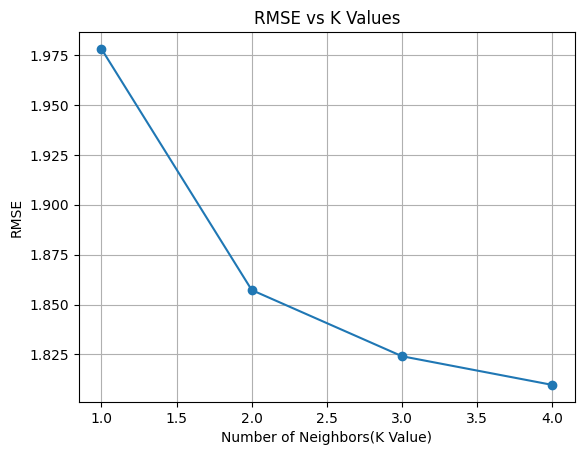

In [44]:
reader=Reader(rating_scale=(1,10))
train_data=Dataset.load_from_df(ratings[['User-ID','ISBN','Book-Rating']],reader)
test_data=Dataset.load_from_df(ratings_test[['User-ID','ISBN','Book-Rating']],reader)

#define a appropriate range of k value
#k value betweeen 1 and 5 is for reducing run time
#The output rmse doesn't change with k value. I will discuss why in report.
kvalues=np.arange(1,5)
result=[]
for k in kvalues:
    options={'name':'msd','user_based':False}
    model=KNNBasic(k=k,sim_options=options)
    cv_result=cross_validate(model,train_data,cv=5,verbose=False)
    mean_rmse=np.mean(cv_result['test_rmse'])
    result.append(mean_rmse)

optimal_k=kvalues[np.argmin(result)]
print(f'Optimal k value is {optimal_k}.')

plt.plot(kvalues,result,marker='o')
plt.title('RMSE vs K Values')
plt.xlabel('Number of Neighbors(K Value)')
plt.ylabel('RMSE')
plt.grid(True)

trainset=train_data.build_full_trainset()
model=KNNBasic(k=optimal_k,sim_options=options)
model.fit(trainset)

testset=test_data.build_full_trainset().build_testset()
prediction=model.test(testset)
accuracy=rmse(prediction)

user base

In [45]:
reader=Reader(rating_scale=(1,10))
train_data=Dataset.load_from_df(ratings[['User-ID','ISBN','Book-Rating']],reader)
test_data=Dataset.load_from_df(ratings_test[['User-ID','ISBN','Book-Rating']],reader)

#same process as item base but set user base option as True
kvalues=np.arange(1,5)
result=[]
for k in kvalues:
    options={'name':'msd','user_based':True}
    model=KNNBasic(k=k,sim_options=options)
    cv_result=cross_validate(model,train_data,cv=5,verbose=False)
    mean_rmse=np.mean(cv_result['test_rmse'])
    result.append(mean_rmse)

optimal_k=kvalues[np.argmin(result)]
print(f'Optimal k value is {optimal_k}.')

plt.plot(kvalues,result,marker='o')
plt.title('RMSE vs K Values')
plt.xlabel('Number of Neighbors(K Value)')
plt.ylabel('RMSE')
plt.grid(True)

trainset=train_data.build_full_trainset()
model=KNNBasic(k=optimal_k,sim_options=options)
model.fit(trainset)

testset=test_data.build_full_trainset().build_testset()
prediction=model.test(testset)
accuracy=rmse(prediction)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
